# Georg-August-Universität Göttingen - Mapping

In [1]:
from google.cloud import bigquery
import pandas as pd
from typing import Union
import re
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
sns.set_style('whitegrid')
plt.rc('font', family='Arial')
plt.rc('font', size=9) 
plt.rc('axes', titlesize=9) 
plt.rc('axes', labelsize=9) 
plt.rc('xtick', labelsize=9) 
plt.rc('ytick', labelsize=9) 
plt.rc('legend', fontsize=9)

In [3]:
client = bigquery.Client(project='subugoe-collaborative')

In [4]:
oal = client.query(f"""
                    SELECT 
                        'not assigned' AS inst_name,
                        'Georg-August-Universität Göttingen' AS parent_name,
                        raw_affiliation_string,
                        openalex_id
                    FROM (
                      SELECT oal.id AS openalex_id, kb_inst.inst_id, inst.address_full AS raw_affiliation_string
                      FROM `subugoe-collaborative.resources.kb_a_addr_inst_202601` AS inst
                      JOIN `subugoe-collaborative.resources.add_institution_lookup_kb_suppl_202601` AS kb_inst
                          ON inst.inst_id_top = kb_inst.inst_id
                      JOIN `subugoe-collaborative.openalex_walden.works` AS oal
                          ON CONCAT('https://openalex.org/', inst.item_id) = oal.id
                      WHERE oal.type IN ('article', 'review') 
                          AND kb_inst.inst_id IN (
                              142 -- 'Georg-August-Universität Göttingen'
                          )
                          AND is_paratext=FALSE 
                          AND is_retracted=FALSE 
                          AND is_xpac=FALSE
                          AND publication_year BETWEEN 2020 AND 2025
                    )
                    """).to_dataframe()

In [5]:
oal.head()

,inst_name,parent_name,raw_affiliation_string,openalex_id
0,not assigned,Georg-August-Universität Göttingen,"Department of Nephrology and Rheumatology, Uni...",https://openalex.org/W4229453796
1,not assigned,Georg-August-Universität Göttingen,"Department of Neonatology, Clinic for Paediatr...",https://openalex.org/W4206936848
2,not assigned,Georg-August-Universität Göttingen,"Forest Genetics and Forest Tree Breeding, Geor...",https://openalex.org/W4205323371
3,not assigned,Georg-August-Universität Göttingen,Center for Integrated Breeding Research (CiBre...,https://openalex.org/W4205323371
4,not assigned,Georg-August-Universität Göttingen,"Department of Cardiology and Pneumology, Heart...",https://openalex.org/W4226249746


In [6]:
MAPPING_DICT = {
    'Bernstein Zentrum für Computational Neuroscience Göttingen': ['computational neuroscience', 'bernstein zentrum'], # selbst ergänzt
    'Campus Institut für Dynamik biologischer Netzwerke (CIDBN)': ['biological networks'],
    'Campus-Institut Data Science (CIDAS)': ['cidas', 'campus institute data science'],
    'Centre for Modern Indian Studies (CeMIS)': ['cent(er|re) for modern indian studies'],
    'Center for Integrated Breeding Research (CiBreed)': ['int\w* breeding'], # selbst ergänzt
    #'Courant Forschungszentrum Armut, Ungleichheit und Wachstum in Entwicklungsländern': [],
    #'Courant Forschungszentrum Bildung und Religion': [],
    #'Courant Forschungszentrum Evolution des Sozialverhaltens': [],
    #'Courant Forschungszentrum Nanospektroskopie und Röntgenbildgebung': [],
    #'Courant Forschungszentrum Geobiologie': [],
    #'Courant-Forschungszentrum Textstrukturen': [],
    #'DFG Forschungszentrum für Molekularphysiologie des Gehirns': [],
    #'Erasmus Mundus Programme Euroculture - Society, politics and culture in a global context': [],
    'Fakultät für Agrarwissenschaften': ['landwirtschaftlich', 'agricultural', 'breeding research', 'veterinary', '(animal|crop) (science|plant)', 'mycotoxin',
                                         'agro(ecology|biodiversity|nomy)', 'biogeochemistry', 'plant pathology', 'animal (medicine|hygiene)', 'husbandry',
                                         'agrarökonomie', 'grassland', 'tierärztliches institut', 'agrarökosysteme', 'plant breeding'
                                        ],
    'Fakultät für Biologie und Psychologie': ['biolog(ie|y) (and|und|&) psycholog(ie|y)', 'blumenbach', 'evolution of plants', 'georg-elias', 'conservation biology',
                                              '(department|institute) of psychology', '(animal|human|behavioral) ecology', 'climate dynamics', 'applied bioinformatics',
                                              'cent(er|re) (of|for) molecular biosciences', 'von(-|‐|\s)haller', 'plant cell biology', 'zoology and anthropology',
                                              'enzymology', '(educational|developmental|experimental) psychology', 'plant ecology', 'zelluläre neurobiologie',
                                              'mi(k|c)robiolog(ie|y) (und|and|&amp;) geneti(k|cs)', 'behavioural biology', 'plant biochemistry',
                                              '(socio|neuro)biology', 'psychologie und psychotherapie', 'molecular structural biology', 'biology education',
                                              'psychology of language', 'phycology', '(general|applied) microbiology', 'developmental biology',
                                              'vegetation', '(abteilung|animal) evolution', 'molecular oncology', 'genomic', ' social and communication',
                                              'evolutionary developmental', 'zentrum für molekulare biowissenschaften', 'department of bioinformatics'
                                             ],
    'Fakultät für Chemie': ['(physi(kalische|cal)|(an|in)organi(sche|c)) chemi(e|st(r)?y)', 'biomole(k|c)ular', '(faculty|department) of chemistry', 'w(ö|oe)hler',
                            'sustainable materials and chemistry', 'organic chemistry'
                           ],
    'Fakultät für Forstwissenschaften und Waldökologie': ['centre of biodiversity', 'forest', 'wood', 'biogeography', 'ecosystem modelling',
                                                          'radio(‐|-)?isotopes', '(soil|wildlife) science', 'stable isotope', 'bioclimatology',
                                                          'wildlife', 'forstwissenschaften', 'conservation policy'
                                                         ],
    'Fakultät für Geowissenschaften und Geographie': ['geo(dynamics|science)', 'mineralog(ie|y)', 'geowissenschaftliches zentrum', '(physical|human) geography',
                                                      'sedimentology', 'cartography', '(angewandte|applied|isotope) geolog(ie|y)', 'geoscientific',
                                                      '(department|institute) of geo(biology|graphy)', 'abt(.|eilung) geochemie', 'geographisches'
                                                     ],
    'Fakultät für Mathematik und Informatik': ['computer science', 'mathemati(k|cs|sch)', 'stochastic', 'bernstein‐institute', 'institut(e)? (für|of) informati(k|cs)',
                                               'maschinelles lernen', 'computer security', 'breeding informatics', 'mathematical institute'
                                              ],
    'Fakultät für Physik': ['geophysik', 'complex systems', 'friedrich-hund', 'x(‐|-)ray physics', 'physics—biophysics', 
                            '(institute|fa(k|c)ult(ät|y)|department) (der|für|of) physi(k|cs)', 
                            'physi(kalisches|cal) institut(e)?', 'theoreti(sche|cal) physi(k|cs)', 'materials physics', '(astro|röntgen)physik', 'didaktik der physik',
                            'physics education'
                           ],
    #'Forum für interdisziplinäre Religionsforschung (FiReF)': [],
    'Gesellschaft für wissenschaftliche Datenverarbeitung mbH Göttingen': ['gwdg', 'escience', 'gesellschaft für wissenschaftliche datenverarbeitung'],
    #'Graduiertenschule für Geisteswissenschaften Göttingen (GSGG)': [],
    'Göttinger Graduiertenzentrum für Neurowissenschaften': ['center nanoscale microscopy', 'molecular biosciences'], 
    #'Göttinger Graduiertenzentrum für Neurowissenschaften, Biophysik und Molekulare Biowissenschaften (GGNB)'
    #'Informationsverbund Dermatologischer Kliniken (IVDK)': [],
    #'Interdisziplinäres Zentrum für Nachhaltige Entwicklung': [],
    'Juristische Fakultät': ['(rechts|kriminal)wissenschaften', '(bio|medizin|jugendstraf|landwirtschafts|arbeits|europa|familien)recht', 'faculty of law', 'labour law', 
                             'juristische fakultät'
                            ],
    'Lichtenberg-Kolleg': ['lichtenberg'],
    'Niedersächsische Staats- und Universitätsbibliothek': ['bibliothek', 'library', 'papendiek 14', 'sub göttingen'],
    'Philosophische Fakultät': ['arch(a)?eology', '(früh|neuere)(\s)?geschichte', 'english', 'philo(soph|log(ie|y))', 'sprachwissenschaft', 
                                '(iranian|(east )?asian|romance) studies', 'protohistory', 'romance languages', 'musicol(ogy)?',
                                'cultural anthropology', 'faculty of humanities', '(early|regional|modern) history', '(althistorisches|skandinavisches) seminar'
                               ],
    #'Sonderforschungsbereich 1136': [],
    'Sozialwissenschaftliche Fakultät': ['(institut(e)?|faculty) (für|of) (so(z|c)i|political)', 'sociological research institute', 'democracy (research|studies)',
                                         '(sport(s)?|political|educational) science', '(politik|sport|erziehungs)wissenschaft', 'soziologisches',
                                         'erziehungswissensch'
                                        ],
    'Theologische Fakultät': ['theologische fakultät'],
    'Universitätsmedizin Göttingen (UMG)': ['univ(ersi(t)?((ä|a|ae)ts|y))?(\s|\sof\s)?(med|hosp|klinik)', 'gyn(äk|ec)olog(ie|y)', 'dentistry', 'cardiovascular',
                                            'medical (university )?(cent(re|er)|school|clinic|science)?', 'neuroimmunology', 'cardiology', 'psychosomatic',
                                            'h((a)?e|ä)matolog(ie|y)', 'radiolog(ie|y)', 'neurology', 'medical (bio)?informatics', 'pneumology', 'augenklinik',
                                            'pharmacology', 'an(a)?esthesiology', 'bioimaging', 'psychiatry', 'psychoneuroscience', 'dental', 'anatomy',
                                            'heart cent(er|re)', 'palliativmedizin', 'cellular biophysics', 'medizinische statistik', 'nephrology',
                                            'infektiologie', '(trauma|neuro|thoracic|neck)(\s)?surgery', 'epidemiology', 'medizin und psychotherapie',
                                            'otorhinolaryngology', 'maxillofacial', 'jugendpsychiatrie', 'molecular cell', 'gastroenterolog(ie|y)',
                                            'otolaryngology', '889', '1690', '1286', 'faculty of medicine', 'department of dermatology',
                                            'nuclear medicine', 'orthop(a)?edics', '(gesichts|unfall)chirurgie', 'hno(\s|-)(klinik|göttingen)',
                                            'cellular biochemistry', 'forensisch', 'geriatrics', 'frauenheilkunde', "children's hospital",
                                            'klinik für psychiatrie', 'neuropathology', 'pediatrics', 'clinical psychology', 'ophthalmol',
                                            'cardiovasc'
                                           ],
    'Wirtschaftswissenschaftliche Fakultät': ['econometrics', 'innovation', 'department of economics', 'economic (sciences|policy)', 'business and economics',
                                              'business (education|administration|economics)', 'logistics', '(professur|chair) (für|of) statisti(k|cs)',
                                              'information(s|\s)(management|systems)', 'anwendungssysteme', 'application systems', 'sozialgeschichte',
                                              '(development|public) economics', 'rechnungslegung', 'wirtschaftspädagogik', 'management and control', 
                                              'information security', 'volkswirtschaftslehre'
                                             ],
    #'Zentrale Kustodie': [],
    #'Zentrum für Antike und Orient': [],
    'Zentrum für Biodiversität und Nachhaltige Landnutzung': ['cent(er|re) (for|of) (biodiversity|sustainable)'],
    #'Zentrum für empirische Unterrichts- und Schulforschung (ZeUS)': [],
    #'Zentrum für Globale Migrationsstudien (CeMig)': [],
    'Zentrum für Statistik': ['zentrum für statistik'],
    #'ZESS - Zentrale Einrichtung für Sprachen und Schlüsselqualifikationen': []
}

In [7]:
df_with_inst = oal.copy()

In [8]:
def map_address(address: str) -> Union[str, None]:
    for k, v in MAPPING_DICT.items():
        pattern = re.compile(r'|'.join(v), re.IGNORECASE)
        res = bool(pattern.search(address))
        if res:
            return k
    return None

In [9]:
df_with_inst.loc[df_with_inst['inst_name'] == 'not assigned', 'inst_name'] = \
           df_with_inst.loc[df_with_inst['inst_name'] == 'not assigned']['raw_affiliation_string'].apply(map_address)

In [10]:
df_with_inst

,inst_name,parent_name,raw_affiliation_string,openalex_id
0,Universitätsmedizin Göttingen (UMG),Georg-August-Universität Göttingen,"Department of Nephrology and Rheumatology, Uni...",https://openalex.org/W4229453796
1,Universitätsmedizin Göttingen (UMG),Georg-August-Universität Göttingen,"Department of Neonatology, Clinic for Paediatr...",https://openalex.org/W4206936848
2,Fakultät für Forstwissenschaften und Waldökologie,Georg-August-Universität Göttingen,"Forest Genetics and Forest Tree Breeding, Geor...",https://openalex.org/W4205323371
3,Center for Integrated Breeding Research (CiBreed),Georg-August-Universität Göttingen,Center for Integrated Breeding Research (CiBre...,https://openalex.org/W4205323371
4,Universitätsmedizin Göttingen (UMG),Georg-August-Universität Göttingen,"Department of Cardiology and Pneumology, Heart...",https://openalex.org/W4226249746
...,...,...,...,...
37700,Fakultät für Physik,Georg-August-Universität Göttingen,"Institut fr Astrophysik, Georg-August-Universi...",https://openalex.org/W3122022873
37701,Fakultät für Agrarwissenschaften,Georg-August-Universität Göttingen,"Laboratory Animal Science Unit, German Primate...",https://openalex.org/W3170520935
37702,Universitätsmedizin Göttingen (UMG),Georg-August-Universität Göttingen,"Department of Medical Bioinformatics, Universi...",https://openalex.org/W3209477824
37703,Universitätsmedizin Göttingen (UMG),Georg-August-Universität Göttingen,"Department of Experimental Neurodegeneration, ...",https://openalex.org/W3158654074


In [11]:
df_with_inst[df_with_inst.inst_name.isnull()].raw_affiliation_string.unique()[140:160]

array(['University of Göttingen, Göttingen, Deutschland',
       'Institut für angewandte Biotechnologie der Tropen e.V., University of Göttingen, Göttingen, Germany',
       'Georg‐August‐Universität GÖttingen',
       'Georg-August-University of Göttingen',
       'Georg-August-Universität Göttingen, Göttingen, Germany',
       'Georg August Universität Göttingen, Biological and Psychological science, Göttingen, Germany',
       'DARE University of Göttingen Göttingen Germany',
       'Georg August University of Göttingen',
       'Universität Göttingen, Germany',
       'der Georg-August-Universität Göttingen',
       'Georg August University Goettingen, Germany',
       'Georg August University Goettingen, Germany; Leibniz ScienceCampus Primate Cognition, Germany',
       'Biotechnology Center (Biotechnikum), University of Göttingen, Göttingen, Germany',
       'Vertretungsprofessur für Gesellschaft und Wirtschaft Chinas, Georg-August-Universität Göttingen, Göttingen, Deutschland',

In [12]:
df_with_inst[df_with_inst.inst_name.isnull()].groupby('raw_affiliation_string')['openalex_id'].count().reset_index().sort_values(by='openalex_id', ascending=False)[170:200]

,raw_affiliation_string,openalex_id
1652,"University of Göttingen ,",2
1651,University of Göttingen (Germany),2
1197,International Center for Advanced Studies of E...,2
834,"Georg-August-Universität Göttingen, Heinrich-D...",2
676,"Georg-August-Universitt, Gttingen, Germany",2
969,Gottingen University Germany,2
23,"5University of Göttingen, Göttingen, Germany",2
679,Georg-August-University = Georg-August-Univers...,2
1637,University of Gottingen: Georg-August-Universi...,2
1200,International Center for Advanced Studies of E...,2


In [13]:
df_with_inst.groupby(['inst_name'], dropna=False)['openalex_id'].count().reset_index()

,inst_name,openalex_id
0,Bernstein Zentrum für Computational Neuroscien...,106
1,Campus Institut für Dynamik biologischer Netzw...,57
2,Campus-Institut Data Science (CIDAS),194
3,Center for Integrated Breeding Research (CiBreed),288
4,Centre for Modern Indian Studies (CeMIS),178
5,Fakultät für Agrarwissenschaften,2975
6,Fakultät für Biologie und Psychologie,3448
7,Fakultät für Chemie,1677
8,Fakultät für Forstwissenschaften und Waldökologie,2644
9,Fakultät für Geowissenschaften und Geographie,1085


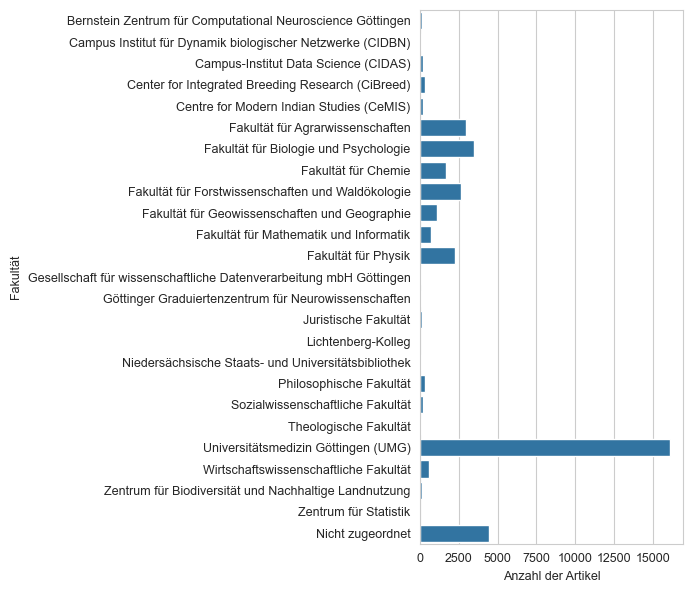

In [14]:
df_plot = df_with_inst.groupby(['inst_name'], dropna=False)['openalex_id'].count().reset_index()
df_plot.fillna('Nicht zugeordnet', inplace=True)

fig, ax = plt.subplots(figsize=(7, 6))

sns.barplot(data=df_plot, 
            x='openalex_id', 
            y='inst_name',
            ax=ax)

ax.set(xlabel='Anzahl der Artikel', ylabel='Fakultät')

plt.tight_layout()

plt.show()

In [15]:
df_plot[df_plot.inst_name != 'Nicht zugeordnet'].openalex_id.sum() / df_plot.openalex_id.sum()

0.8816602572603103